Uppgift: Rena data. Bygg regressionsmodell och analysera prestanda. Vi ska säga om modellen är statistiskt signifikant.
Runt 10 variabler i ett dataset räcker att presentera, som en data-story.
10-15 minuters presentation då det är mer data att jobba mot.

Idé: Ta ett dataset för AirBnb Stockholm, rena data och bytt regressionsmodell, förslagsvis kan vi prediktera pris per natt.
Dataset: AirBnb (https://insideairbnb.com/)
listings.csv	Summary information and metrics for listings in Stockholm (good for visualisations).

In [28]:
import pandas as pd

# Bekanta oss med datasetet!

df = pd.read_csv('data/airbnb_listings_stockholm_detailed.csv')
print("5 första posterna (df.head()):")
print(df.head())

print("5 slumpmässiga poster (df.sample(5)):")
print(df.sample(5))

print("Statistik på alla numeriska kolumneriska kolumner (df.describe):")
print(df.describe())          # statistik på alla numeriska kolumner

print("Hur många observationer per område (df['neighbourhood'])")
print(df['neighbourhood'].value_counts())  # hur många i varje område

print("df.info()")
print(df.info())

5 första posterna (df.head()):
       id                          listing_url       scrape_id last_scraped  \
0  164448  https://www.airbnb.com/rooms/164448  20250929042406   2025-09-29   
1  220851  https://www.airbnb.com/rooms/220851  20250929042406   2025-09-29   
2  238411  https://www.airbnb.com/rooms/238411  20250929042406   2025-09-29   
3  242188  https://www.airbnb.com/rooms/242188  20250929042406   2025-09-29   
4  273906  https://www.airbnb.com/rooms/273906  20250929042406   2025-09-29   

        source                                         name  \
0  city scrape  Double room in central Stockholm with Wi-Fi   
1  city scrape                      One room in appartement   
2  city scrape          Cozy apartment in central Stockholm   
3  city scrape  Single room in central Stockholm with Wi-Fi   
4  city scrape               Penthouse in central Stockholm   

                                         description  \
0  I am renting out a nice double room on the top...   
1  

Rena lite data

In [29]:
# Ändra price från str till int

cleandf = df
cleandf['price'] = cleandf['price'].str.replace('$','')
cleandf['price'] = cleandf['price'].str.replace(',','')
cleandf['price'] = cleandf['price'].astype(float)




In [30]:
# Kolla priser, något är extremt högt vilket skevar analysen 112218
print(cleandf['price'].describe())

print(cleandf['price'].max())



count      3190.000000
mean       1690.473041
std        3704.741906
min         120.000000
25%         753.000000
50%        1200.000000
75%        2000.000000
max      112218.000000
Name: price, dtype: float64
112218.0


In [31]:
# Exportera till Excel för enklare granskning
import openpyxl
df.to_excel('airbnb_stockholm.xlsx', index=False)

Gör en pairplot som ska vara kung för att analysera data visuellt.

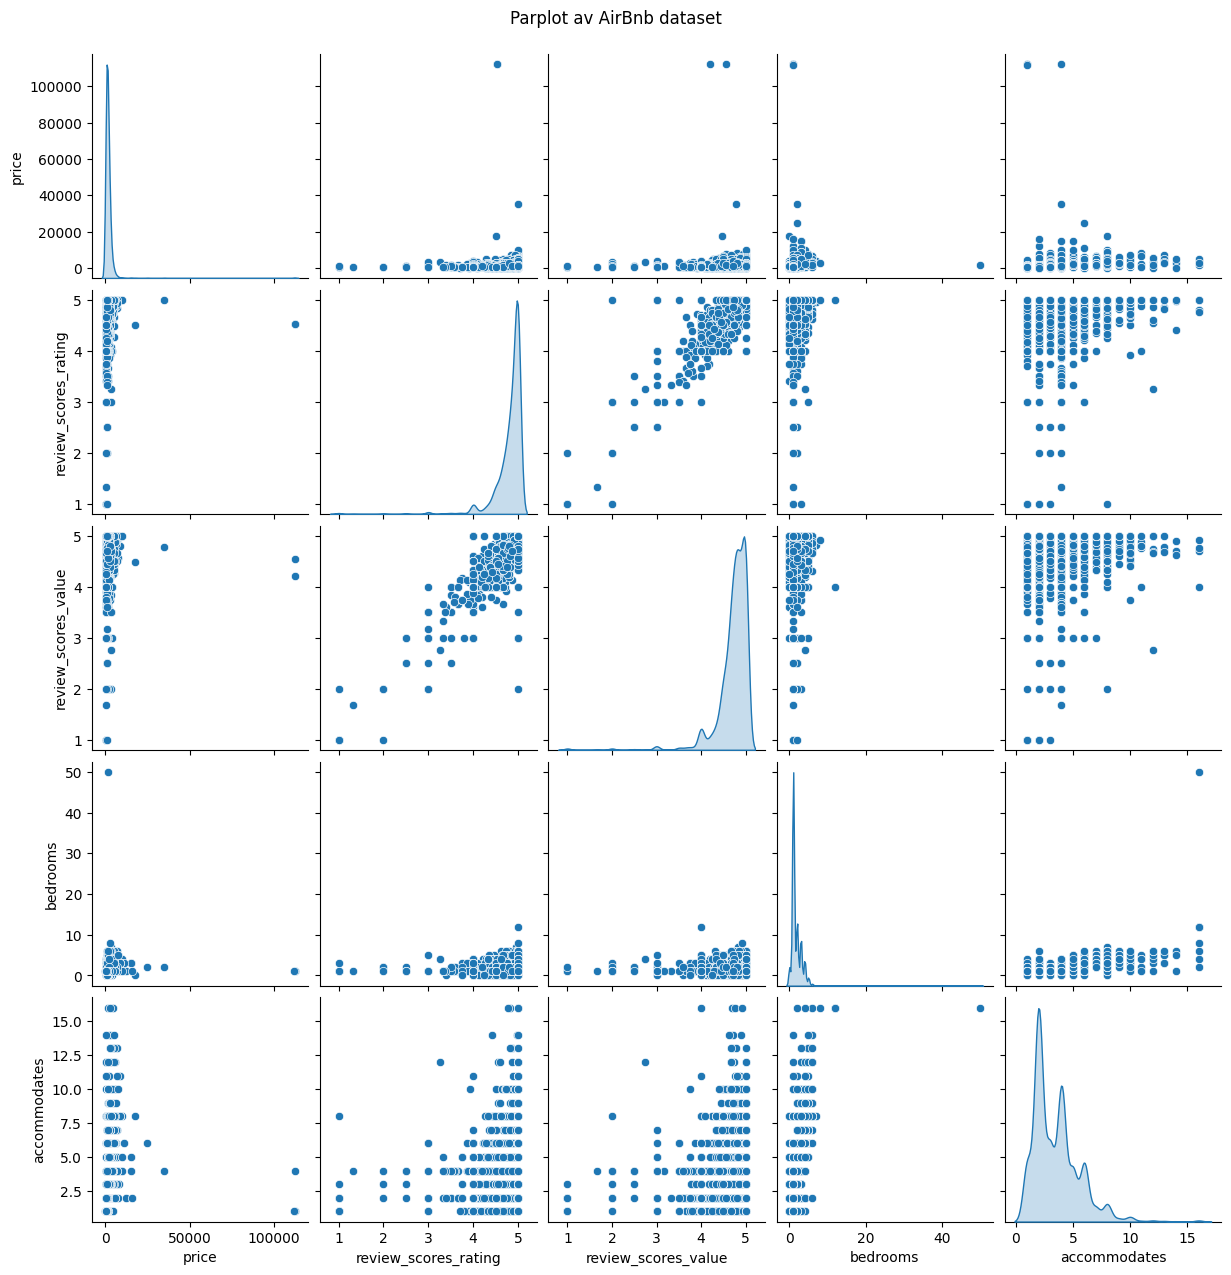

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

cols = ['price','review_scores_rating','review_scores_value','room_type','bedrooms','accommodates']

pp = sns.pairplot(cleandf[cols], diag_kind='kde')
pp.figure.suptitle('Parplot av AirBnb dataset', y=1.02)

plt.show()

...